In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from collections import Counter
from itertools import combinations
import seaborn as sns
warnings.filterwarnings("ignore")

In [2]:
# Load data
df = pd.read_csv("train.csv")

In [3]:
def plot_distribution_summary(
    df,
    field_name,
    top_n=20,
    percentiles=(0.25, 0.50, 0.75),
    figsize=(18, 5),
    rotate_xticks=45,
):
    total_unique = df[field_name].nunique(dropna=False)
    print(f"Total unique '{field_name}': {total_unique:,}")

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # ==========================
    # Left: Top-N Histogram
    # ==========================
    counts = (
        df[field_name]
        .value_counts(dropna=False)
        .head(top_n)
    )

    axes[0].bar(counts.index.astype(str), counts.values)
    axes[0].set_title(f"Top {top_n} '{field_name}'\n(Total unique: {total_unique:,})")
    axes[0].set_xlabel(field_name)
    axes[0].set_ylabel("Count")
    axes[0].tick_params(axis="x", rotation=rotate_xticks)

    # ==========================
    # Right: Cumulative Distribution
    # ==========================
    all_counts = df[field_name].value_counts().values
    counts_sorted = np.sort(all_counts)

    cum_counts = np.cumsum(counts_sorted)
    cum_counts_norm = cum_counts / cum_counts[-1]

    axes[1].plot(range(len(counts_sorted)), cum_counts_norm)

    default_colors = [
        "red",
        "green",
        "blue",
        "orange",
        "purple",
        "brown",
        "black",
    ]

    for i, p in enumerate(percentiles):
        idx = np.searchsorted(cum_counts_norm, p)

        axes[1].axvline(
            idx,
            color=default_colors[i % len(default_colors)],
            linestyle="--",
            label=f"{p*100:.0f}% @ {idx}",
        )

        axes[1].scatter(idx, cum_counts_norm[idx], color=default_colors[i % len(default_colors)])

    axes[1].set_xlabel(f"Index (sorted {field_name} count)")
    axes[1].set_ylabel("Cumulative proportion")
    axes[1].set_title(f"Cumulative Distribution of {field_name}")
    axes[1].set_ylim(0, 1)
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

Total unique 'brand': 377


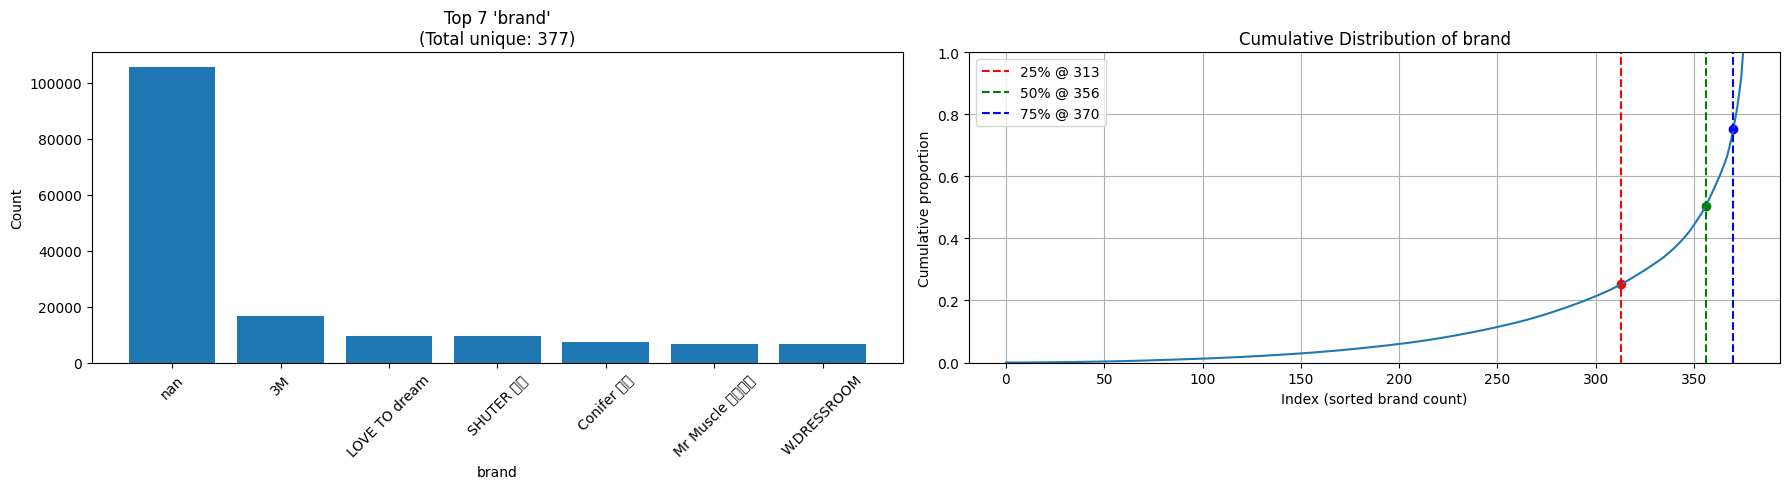

In [4]:
plot_distribution_summary(df, "brand", top_n=7, percentiles=(0.25, 0.5, 0.75))

Total unique 'shopId': 219


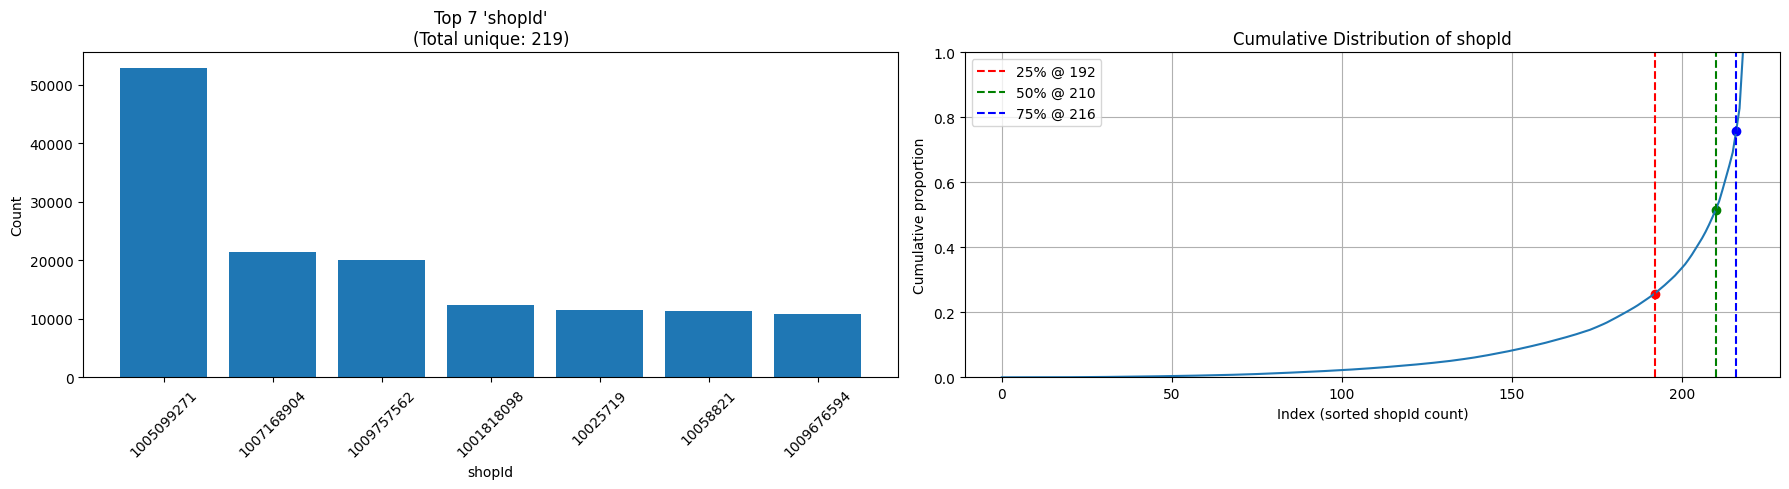

In [5]:
plot_distribution_summary(df, "shopId", top_n=7, percentiles=(0.25, 0.5, 0.75))

Total unique 'cat_id': 26


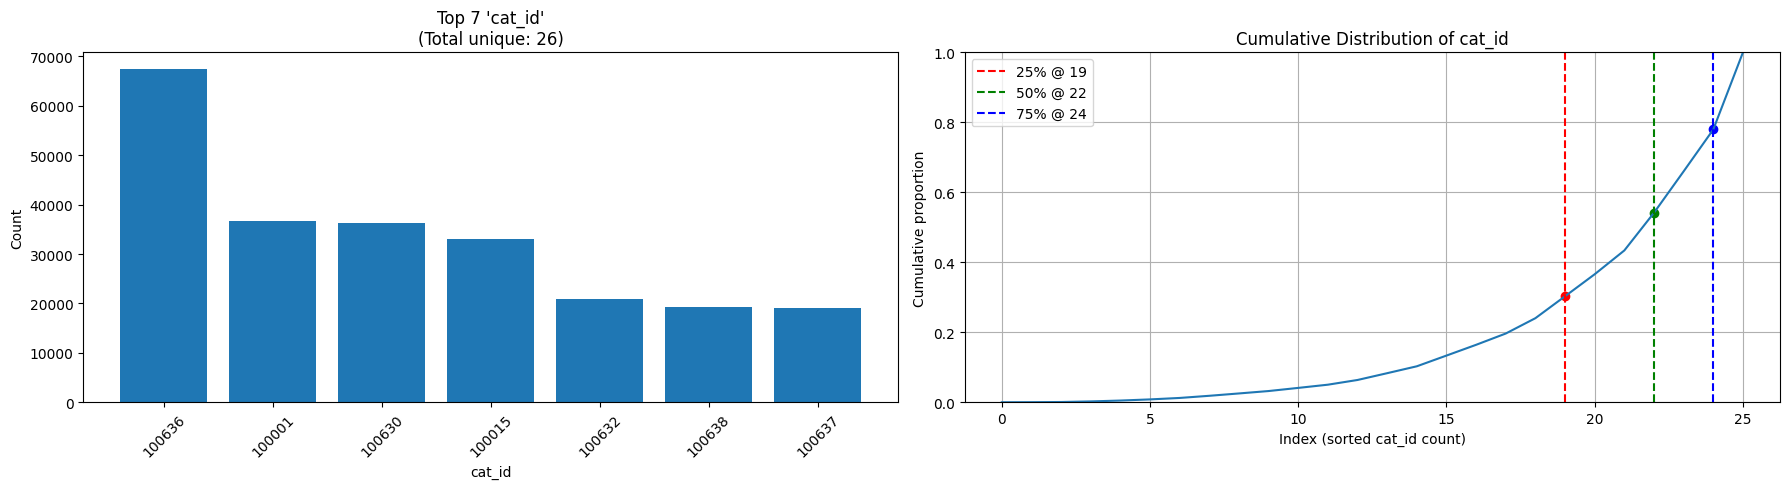

In [6]:
plot_distribution_summary(df, "cat_id", top_n=7, percentiles=(0.25, 0.5, 0.75))

Total unique 'modelId': 6,286


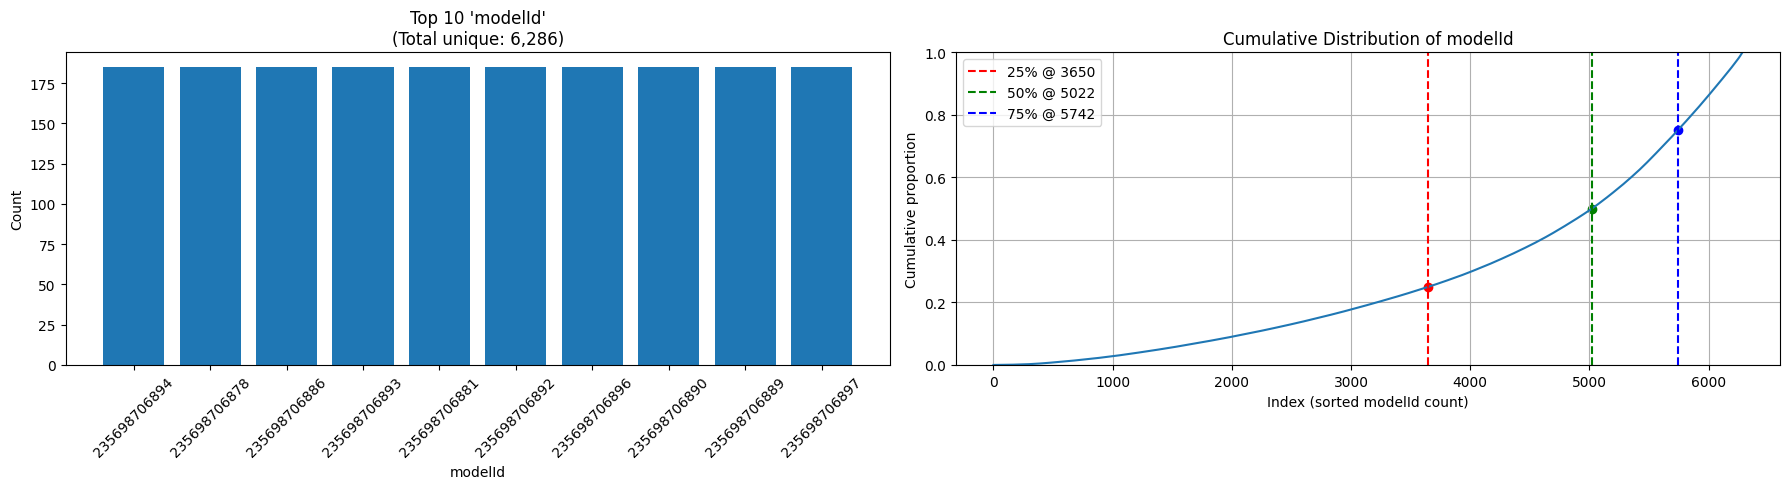

In [7]:
plot_distribution_summary(df, "modelId", top_n=10, percentiles=(0.25, 0.5, 0.75))

Total unique 'itemId': 1,594


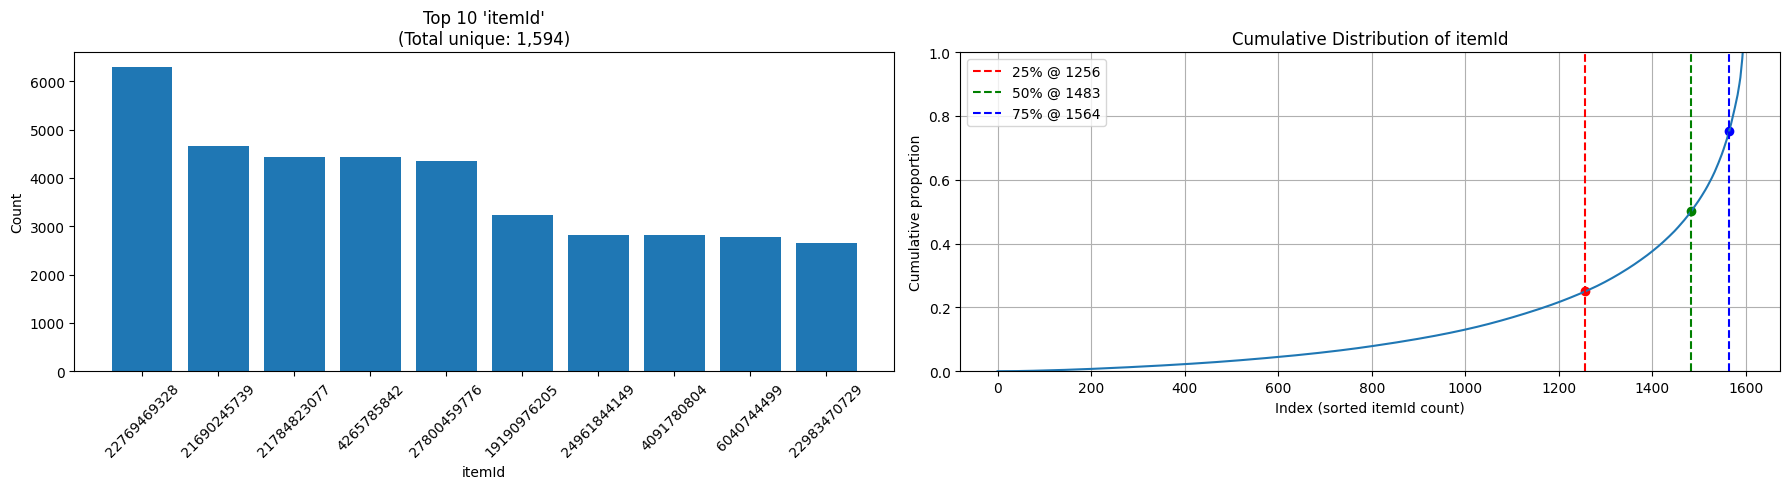

In [8]:
plot_distribution_summary(df, "itemId", top_n=10, percentiles=(0.25, 0.5, 0.75))

## Relation between Field IDs

In [9]:
def analyze_relationship(df, field_1, field_2):
    pair_df = (
        df[[field_1, field_2]]
        .drop_duplicates(ignore_index=True)
    )

    field_1_summary = (
        pair_df.groupby(field_1, as_index=False)
        .agg(
            values=(field_2, list),
            count=(field_2, "size"),
        )
        .sort_values("count", ascending=False)
        .reset_index(drop=True)
    )

    field_2_summary = (
        pair_df.groupby(field_2, as_index=False)
        .agg(
            values=(field_1, list),
            count=(field_1, "size"),
        )
        .sort_values("count", ascending=False)
        .reset_index(drop=True)
    )

    field_1_max = field_1_summary["count"].max()
    field_2_max = field_2_summary["count"].max()

    if field_1_max == 1 and field_2_max == 1:
        relationship = "One-to-One"
    elif field_1_max > 1 and field_2_max == 1:
        relationship = "One-to-Many"
    elif field_1_max == 1 and field_2_max > 1:
        relationship = "Many-to-One"
    else:
        relationship = "Many-to-Many"

    return (
        pair_df,
        field_1_summary,
        field_2_summary,
        relationship,
    )

In [10]:
field_ids = ["shopId", "itemId", "modelId", "cat_id", "brand"]

relationship_pairs = list(combinations(field_ids, 2))

relationship_summary = []

for field_1, field_2 in relationship_pairs:
    (
        pair_df,
        field_1_summary,
        field_2_summary,
        relationship,
    ) = analyze_relationship(
        df=df,
        field_1=field_1,
        field_2=field_2,
    )

    relationship_summary.append({
        "field_1": field_1,
        "field_2": field_2,
        "relationship": relationship,
        "unique_field_1": pair_df[field_1].nunique(),
        "unique_field_2": pair_df[field_2].nunique(),
        "unique_pairs": len(pair_df),
        "field_1_max_links": field_1_summary["count"].max(),
        "field_1_mean_links": field_1_summary["count"].mean(),
        "field_2_max_links": field_2_summary["count"].max(),
        "field_2_mean_links": field_2_summary["count"].mean(),
    })

df_relationship_summary = (
    pd.DataFrame(relationship_summary)
    .sort_values(["field_1", "field_2"])
    .reset_index(drop=True)
)

In [11]:
df_relationship_summary

,field_1,field_2,relationship,unique_field_1,unique_field_2,unique_pairs,field_1_max_links,field_1_mean_links,field_2_max_links,field_2_mean_links
0,cat_id,brand,Many-to-Many,26,376,451,86,17.346154,7,1.138298
1,itemId,brand,Many-to-Many,1594,376,1597,2,1.001882,116,3.409574
2,itemId,cat_id,Many-to-Many,1594,26,1597,2,1.001882,489,61.423077
3,itemId,modelId,One-to-Many,1594,6286,6286,63,3.943538,1,1.000000
4,modelId,brand,Many-to-Many,6286,376,6308,2,1.003500,259,11.803191
5,modelId,cat_id,Many-to-Many,6286,26,6311,2,1.003977,1735,242.730769
6,shopId,brand,Many-to-Many,219,376,550,34,2.511416,6,1.178191
7,shopId,cat_id,Many-to-Many,219,26,343,15,1.566210,82,13.192308
8,shopId,itemId,One-to-Many,219,1594,1594,123,7.278539,1,1.000000
9,shopId,modelId,One-to-Many,219,6286,6286,565,28.703196,1,1.000000
